# Классификация ботов — исследование и выбор модели

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import (
    SEED, RECALL_TARGET, precision_at_recall, events_in_window,
    item_popularity_table, build_base_features, popularity_features,
    event_transition_table, transition_features,
    make_time_folds, cv_predict, numeric_frame,
)

np.random.seed(SEED)

## 1. Данные

In [2]:
train = pd.read_csv("data/train.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv("data/test.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

dup_rows = events.duplicated().sum()
events = events.drop_duplicates().reset_index(drop=True) #убираем дубликаты

print("train/test/events:", train.shape, test.shape, events.shape, " | дублей событий убрано:", dup_rows)
print("доля ботов в train:", train.target.mean().round(4))

train/test/events: (11091, 5) (4909, 4) (324042, 14)  | дублей событий убрано: 4863
доля ботов в train: 0.0811


### График 1. Посмотрим на данные


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train["target"].value_counts().sort_index()
axes[0].bar(["0 — человек", "1 — бот"], counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Баланс классов")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

daily = train.copy()
daily["date"] = daily["window_start_ts"].dt.floor("D")
daily_ct = daily.groupby(["date", "target"]).size().unstack(fill_value=0)
for col in daily_ct.columns:
    axes[1].plot(daily_ct.index, daily_ct[col], marker="o", label=f"target={col}")
axes[1].set_title("Куки по дате начала окна")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1200x400 with 2 Axes>

## 2. Гипотезы
смотрю на данные -> думаю, что проверять/смотреть

1. **H1 — популярность объявлений у одинаковых куки -> предполагаю что чем выше популярность тем вероятнее, что это бот.
2. **H2 — очевидная гипотеза, что больше признаков лучше чем  2 признака и изначальная константа, пишу для статистики
3. **H3 — балансировка классов (`class_weight="balanced"`) даёт прирост над моделью без неё, (т.к. класс бота — 8% выборки)
4. **H4 — ансамбль нескольких моделей лучше лучшей одиночной модели


## 3. Окно наблюдения

Признаки — только по событиям `window_start_ts <= event_ts < window_end_ts`. Это требование
из условия, а не рекомендация: событие после конца окна для модели просто не существует.

In [4]:
ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print("событий в train/test окнах:", len(ev_tr), len(ev_te))

событий в train/test окнах: 195484 88349


captcha_shown показывает почти вероятно что данный кук - бот, проверяем, что он находится вне нашего окна наблюдения

In [5]:
cap_cookies = set(events.loc[events.event_name == "captcha_shown", "cookie_id"])
has_cap = train.cookie_id.isin(cap_cookies)
print("доля ботов среди кук с captcha_shown (когда-либо):", round(train.loc[has_cap, "target"].mean(), 4))
print("доля ботов среди остальных:", round(train.loc[~has_cap, "target"].mean(), 4))
print("captcha_shown внутри train-окна (ev_tr):", (ev_tr.event_name == "captcha_shown").sum())

cap_ev = events[events.event_name == "captcha_shown"].merge(
    train[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id", how="inner")
after_window = (cap_ev.event_ts >= cap_ev.window_end_ts).mean()
print(f"доля captcha_shown СТРОГО после конца окна: {after_window:.1%} из {len(cap_ev)} событий")

доля ботов среди кук с captcha_shown (когда-либо): 0.771
доля ботов среди остальных: 0.0435
captcha_shown внутри train-окна (ev_tr): 0
доля captcha_shown СТРОГО после конца окна: 100.0% из 7831 событий


## 4. Признаки

### 4.1
Паузы между событиями и их распределение (`gap_*`, `burstiness`, `same_gap_frac`) —
предположение: у бота паузы одинаковые/короткие. Энтропии (`hour_entropy`,
`category_entropy`, `event_entropy`) — предположение: у бота ниже, поведение более
предсказуемое. UA-сигнатуры (`okhttp_frac`, `headless_frac`, `botword_frac`) — предположение:
прямые сигнатуры ботов `engagement_frac`/`login_frac` —
предположение: доля "человеческих" действий (избранное, сообщения, логин).

Далее посмотрим связь каждого с 'target'

In [6]:
top_events = ev_tr["event_name"].value_counts().head(15).index.tolist()

Xtr_base = build_base_features(ev_tr, train, top_event_names=top_events)
Xte_base = build_base_features(ev_te, test, top_event_names=top_events)
base_cols = [c for c in Xtr_base.columns if c not in ("cookie_id", "event_search_results_view")]
y = train["target"].to_numpy(dtype=int)

print("базовых признаков:", len(base_cols))
Xtr_base.head()

базовых признаков: 46


,cookie_id,cookie_age_log,n_events,n_unique_events,n_unique_ua,n_unique_platforms,n_unique_categories,n_unique_locations,gap_mean,gap_std,...,login_frac,event_item_view,event_search_results_view,event_photo_swipe,event_favorite_add,event_seller_page_view,event_contact_phone_show,event_login,event_contact_chat_open,event_contact_message_sent
0,ck_54a059eb7d3ea68b,16.276480,7,3,1,3,3,5,27.833333,29.949402,...,0.000000,3,3,1,0,0,0,0,0,0
1,ck_7e4de46eeab82974,16.637566,41,7,1,4,1,12,986.900000,2416.286861,...,0.024390,22,8,4,1,4,1,1,0,0
2,ck_9320229ef6304522,14.863082,36,9,1,4,7,9,1042.600000,2306.449400,...,0.083333,7,13,3,3,3,2,3,1,1
3,ck_30ccd25bc1714ed9,10.763017,21,5,1,4,1,4,861.050000,2502.081501,...,0.000000,14,3,0,0,2,1,0,1,0
4,ck_a77c5f05948cdeef,15.918904,28,6,1,4,4,6,707.333333,1748.439172,...,0.000000,12,6,4,2,3,1,0,0,0


### 4.1.1. Проверяем связь с target

Каждый признак по отдельности: корреляция с `target`, средние по классам, доля кук с
ненулевым значением и  `P@R0.7`

In [7]:
feat_hypotheses = [
    "okhttp_frac", "headless_frac", "botword_frac", "mobile_frac",
    "engagement_frac", "login_frac",
    "hour_entropy", "category_entropy", "event_entropy",
    "same_gap_frac", "same_event_frac", "burstiness",
]

rows = []
for c in feat_hypotheses:
    x = Xtr_base[c].to_numpy(dtype=float)
    rows.append({
        "признак": c,
        "corr_с_target": np.corrcoef(x, y)[0, 1],
        "среднее|бот=1": x[y == 1].mean(),
        "среднее|бот=0": x[y == 0].mean(),
        "доля кук с ненулевым знач.": (x > 0).mean(),
        "P@R0.7": max(precision_at_recall(y, x), precision_at_recall(y, -x)),
    })

feat_table = pd.DataFrame(rows).set_index("признак")
feat_table.sort_values("corr_с_target", key=np.abs, ascending=False).round(4)

,corr_с_target,среднее|бот=1,среднее|бот=0,доля кук с ненулевым знач.,P@R0.7
признак,,,,,
same_gap_frac,0.2799,0.0326,0.0049,0.1163,0.0811
burstiness,0.1807,2.6044,1.8902,0.9413,0.0939
engagement_frac,-0.1603,0.1312,0.2270,0.8583,0.1457
category_entropy,-0.1143,0.3857,0.5824,0.6836,0.1052
headless_frac,0.1080,0.0834,0.0207,0.0258,0.0811
same_event_frac,0.0972,0.3144,0.2473,0.8343,0.1098
mobile_frac,-0.0718,0.3459,0.4771,0.4665,0.0811
login_frac,-0.0605,0.0099,0.0232,0.2626,0.0920
botword_frac,0.0582,0.0389,0.0130,0.0151,0.0811


### 4.2. Признак: одинаковые item_id у разных куки

Для каждой куки считаю среднюю "популярность" объявлений,
которые она смотрела — у скольких **других** куки встречался тот же `item_id`. Предположение: у боты доля одинаковых item_id больше чем у людей т.к. они скорее всего действуют по похожему сценарию.

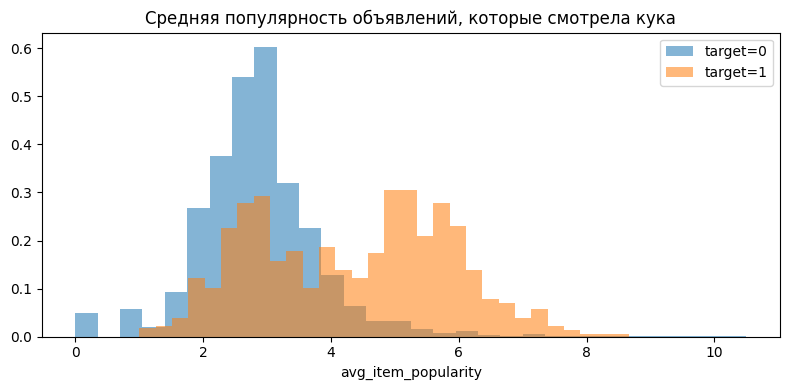

корреляция "популярности" с target: 0.376


In [8]:
# сколько разных куки смотрели один и тот же item_id 
pop_full = item_popularity_table(ev_tr)

ev_pop = ev_tr.dropna(subset=["item_id"]).copy()
ev_pop["item_pop"] = ev_pop["item_id"].map(pop_full)
per_cookie_pop = ev_pop.groupby("cookie_id")["item_pop"].mean()
eda_pop = train[["cookie_id", "target"]].merge(per_cookie_pop.rename("avg_item_popularity"), on="cookie_id", how="left").fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
for target, part in eda_pop.groupby("target"):
    ax.hist(part["avg_item_popularity"], bins=30, alpha=0.55, density=True, label=f"target={target}")
ax.set_title("Средняя популярность объявлений, которые смотрела кука")
ax.set_xlabel("avg_item_popularity")
ax.legend()
plt.tight_layout()
plt.show()

print("корреляция \"популярности\" с target:",
      round(eda_pop["avg_item_popularity"].corr(eda_pop["target"]), 3))

In [9]:
#таблицы популярности и переходов между событиями: для каждого временного промежутка — только по его тренировочной части
folds = make_time_folds(train, n_splits=5)
pop_cols = ["avg_item_popularity", "max_item_popularity", "avg_log_transition_p"]

fold_pop_feats = []
for tm, vm in folds:
    tr_cookies = set(train.loc[tm, "cookie_id"])
    ev_tr_fold = ev_tr[ev_tr.cookie_id.isin(tr_cookies)]
    pop_i = item_popularity_table(ev_tr_fold)
    trans_i = event_transition_table(ev_tr_fold)
    feats_i = popularity_features(ev_tr, pop_i).merge(
        transition_features(ev_tr, trans_i), on="cookie_id", how="left"
    )
    fold_pop_feats.append(feats_i.set_index("cookie_id"))

trans_full = event_transition_table(ev_tr)
Xtr_pop_full = popularity_features(ev_tr, pop_full).merge(
    transition_features(ev_tr, trans_full), on="cookie_id", how="left"
).set_index("cookie_id")
Xte_pop = popularity_features(ev_te, pop_full).merge(
    transition_features(ev_te, trans_full), on="cookie_id", how="left"
).set_index("cookie_id")

## 5. Проверка на разных частях временного промежутка

In [10]:
for i, (tm, vm) in enumerate(folds):
    print(f"fold {i}: train={tm.sum():5d}  valid={vm.sum():5d}  доля ботов в valid={y[vm].mean():.3f}")

fold 0: train= 2403  valid= 2710  доля ботов в valid=0.084
fold 1: train= 5113  valid= 1660  доля ботов в valid=0.072
fold 2: train= 6773  valid= 1627  доля ботов в valid=0.083
fold 3: train= 8400  valid= 1453  доля ботов в valid=0.087
fold 4: train= 9853  valid= 1238  доля ботов в valid=0.076


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

minimal_cols = ["n_events", "n_unique_categories"]
sc_minimal, _ = cv_predict(lambda: HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
                            Xtr_base, y, folds, minimal_cols)

sc_base_nopop, _ = cv_predict(lambda: HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
                               Xtr_base, y, folds, base_cols)

#  тот же набор + популярность объявлений
sc_base_pop, oof_base_pop = cv_predict(lambda: HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
                                        Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols)


pop_cols_popularity = ["avg_item_popularity", "max_item_popularity"]
sc_h1_pop_only, _ = cv_predict(lambda: HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
                                Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols_popularity)

# балансировка классов
sc_unbalanced, _ = cv_predict(lambda: HistGradientBoostingClassifier(random_state=SEED),
                               Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols)

hypotheses = pd.DataFrame([
    ["H1", "популярность объявлений добавляет сигнал", np.mean(sc_h1_pop_only) - np.mean(sc_base_nopop),
     np.mean(sc_h1_pop_only) - np.mean(sc_base_nopop) > 0],
    ["H2", "полный набор признаков > 2 исходных признака(очевидно, но просто для статистики)", np.mean(sc_base_nopop) - np.mean(sc_minimal),
     np.mean(sc_base_nopop) - np.mean(sc_minimal) >= 0.05],
    ["H3", "class_weight='balanced' помогает", np.mean(sc_base_pop) - np.mean(sc_unbalanced),
     np.mean(sc_base_pop) - np.mean(sc_unbalanced) > 0],
], columns=["id", "гипотеза", "наблюдаемая_дельта", "подтверждена"])
hypotheses["наблюдаемая_дельта"] = hypotheses["наблюдаемая_дельта"].round(4)
hypotheses

## 6. Сравнение базовых моделей

In [12]:
baseline_models = {
    "logreg": lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                     LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    "histgb_baseline": lambda: HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, max_leaf_nodes=31,
                                                                l2_regularization=1.0, class_weight="balanced", random_state=SEED),
}

results, oofs = {}, {}
results["histgb_baseline"], oofs["histgb_baseline"] = sc_base_pop, oof_base_pop  # уже посчитан выше, не дублируем работу

sc, oof = cv_predict(baseline_models["logreg"], Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols)
results["logreg"], oofs["logreg"] = sc, oof

table = pd.DataFrame({"model": list(results), "P@R0.7_mean": [np.mean(v) for v in results.values()],
                       "P@R0.7_std": [np.std(v) for v in results.values()]}).sort_values("P@R0.7_mean", ascending=False)
table

,model,P@R0.7_mean,P@R0.7_std
0,histgb_baseline,0.667723,0.055306
1,logreg,0.550610,0.075540


### корреляция признаков с target



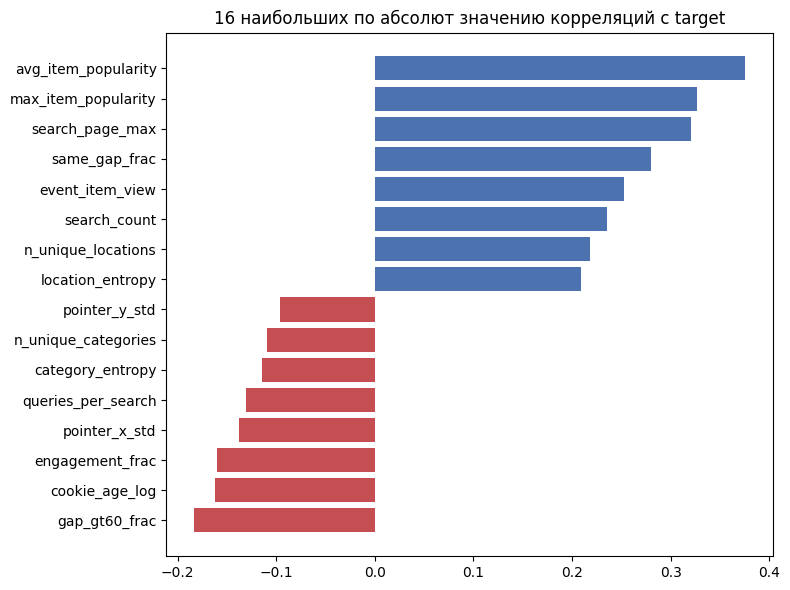

In [13]:
Xtr_full = Xtr_base.set_index("cookie_id").join(Xtr_pop_full, how="left").fillna(0.0).reset_index()
full_cols = base_cols + pop_cols

corr = Xtr_full[full_cols].corrwith(pd.Series(y, index=Xtr_full.index)).sort_values()
top = pd.concat([corr.head(8), corr.tail(8)])

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=["#C44E52" if v < 0 else "#4C72B0" for v in top.values])
ax.set_title("16 наибольших по абсолют значению корреляций с target")
plt.tight_layout()
plt.show()

## 7. Подбор гиперпараметров 

In [14]:
from hpo_search import run_search, LOG_PATH
import pickle

with open("features_cache.pkl", "wb") as f:
    pickle.dump({"Xtr_base": Xtr_base, "y": y, "folds": folds, "fold_pop_feats": fold_pop_feats}, f)

run_search("histgb", Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols, n_iter=10)

[histgb] уже проверено ранее: 235 комбинаций (из hpo_log.csv)
[histgb] лучший результат из прошлых запусков: 0.6899  {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 150, 'max_depth': 8, 'learning_rate': 0.08, 'l2_regularization': 0.5}
[histgb] лучшее за весь лог: 0.6899  {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 150, 'max_depth': 8, 'learning_rate': 0.08, 'l2_regularization': 0.5}


{'score': 0.6899,
 'params': {'min_samples_leaf': 20,
  'max_leaf_nodes': 31,
  'max_iter': 150,
  'max_depth': 8,
  'learning_rate': 0.08,
  'l2_regularization': 0.5},
 'oof': None}

### 7.1. Посмотрим на LightGBM и CatBoost

In [ ]:
import lightgbm as lgb
from catboost import CatBoostClassifier
"значения берутся уже из логгированого csv-файла, если нужно посчитать с новыми -> расскоментировать"
#run_search("lightgbm", Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols, n_iter=30)
#run_search("catboost", Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols, n_iter=30)

log = pd.read_csv(LOG_PATH)
print("всего попыток в логе:", len(log), " | семейства:", log["family"].unique().tolist())
best_per_family = log.loc[log.groupby("family")["mean_score"].idxmax()]
best_per_family[["family", "mean_score", "std_score", "params_json"]].sort_values("mean_score", ascending=False)

всего попыток в логе: 235  | семейства: ['histgb', 'lightgbm', 'catboost']


,family,mean_score,std_score,params_json
34,lightgbm,0.71645,0.06694,"{""subsample"": 1.0, ""scale_pos_weight"": 3.0, ""r..."
67,catboost,0.71022,0.05317,"{""learning_rate"": 0.04, ""l2_leaf_reg"": 7, ""ite..."
140,histgb,0.68990,0.06350,"{""min_samples_leaf"": 20, ""max_leaf_nodes"": 31,..."


In [16]:
from core import cv_overfit_check, robust_best_params

tuned_ctors = {
    "histgb": lambda p: HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED, **p),
    "lightgbm": lambda p: lgb.LGBMClassifier(objective="binary", random_state=SEED, verbosity=-1, **p),
    "catboost": lambda p: CatBoostClassifier(random_seed=SEED, verbose=False, **p),
}

best_params_by_family = {}
overfit_rows = []
for family, ctor in tuned_ctors.items():
    picked = robust_best_params(log, family)
    if picked is None:
        continue
    best_params_by_family[family] = picked["params"]
    tr_sc, va_sc = cv_overfit_check(lambda p=picked["params"], c=ctor: c(p),
                                     Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols)
    overfit_rows.append({
        "family": family,
        "valid_mean_from_log": round(picked["mean_score"], 4),
        "valid_std_from_log": round(picked["std_score"], 4),
        "train_P@R0.7": round(float(np.mean(tr_sc)), 4),
        "valid_P@R0.7_recheck": round(float(np.mean(va_sc)), 4),
        "train_valid_gap": round(float(np.mean(tr_sc) - np.mean(va_sc)), 4),
        "argmax_совпал_с_устойчивым": picked["picked_argmax"],
    })

overfit_table = pd.DataFrame(overfit_rows).sort_values("valid_P@R0.7_recheck", ascending=False)
overfit_table

,family,valid_mean_from_log,valid_std_from_log,train_P@R0.7,valid_P@R0.7_recheck,train_valid_gap,argmax_совпал_с_устойчивым
1,lightgbm,0.6910,0.0374,1.0,0.6910,0.3090,False
2,catboost,0.6583,0.0453,1.0,0.6700,0.3300,False
0,histgb,0.6574,0.0460,1.0,0.6457,0.3543,False


## 8. Ансамбль

In [17]:
import itertools
for family, ctor in tuned_ctors.items():
    if family not in best_params_by_family:
        continue
    params = best_params_by_family[family]
    sc, oof = cv_predict(lambda p=params, c=ctor: c(p), Xtr_base, y, folds, base_cols, fold_pop_feats, pop_cols)
    name = f"{family}_tuned"
    oofs[name] = oof
    results[name] = sc
    print(f"{name}: {np.mean(sc):.4f}  (устойчивый выбор по логу: {params})")

ranked = {name: pd.Series(oof).rank(pct=True).to_numpy() for name, oof in oofs.items()}
names = list(ranked)

def eval_weights(w):
    score = sum(wi * ranked[n] for wi, n in zip(w, names))
    valid = np.isfinite(score)
    return precision_at_recall(y[valid], score[valid])

candidates = []
for i, n in enumerate(names):                             
    w = np.zeros(len(names)); w[i] = 1.0
    candidates.append(w)
for i, j in itertools.combinations(range(len(names)), 2):  
    for wi in np.linspace(0, 1, 21):
        w = np.zeros(len(names)); w[i] = wi; w[j] = 1 - wi
        candidates.append(w)
rng = np.random.default_rng(SEED)                         
candidates += [rng.dirichlet(np.ones(len(names))) for _ in range(3000)]  

best_ens = max(((eval_weights(w), tuple(names), tuple(w)) for w in candidates), key=lambda t: t[0])

print("\nлучший ансамбль (модель: вес):")
for n, w in zip(best_ens[1], best_ens[2]):
    if w > 0.01:
        print(f"  {n}: {w:.3f}")
print("P@R0.7 на CV:", round(best_ens[0], 4))

histgb_tuned: 0.6457  (устойчивый выбор по логу: {'min_samples_leaf': 50, 'max_leaf_nodes': 31, 'max_iter': 500, 'max_depth': 8, 'learning_rate': 0.1, 'l2_regularization': 0.0})
lightgbm_tuned: 0.6910  (устойчивый выбор по логу: {'subsample': 0.9, 'scale_pos_weight': 1.0, 'reg_lambda': 0.5, 'num_leaves': 31, 'n_estimators': 1000, 'min_child_samples': 20, 'learning_rate': 0.02, 'colsample_bytree': 0.7})
catboost_tuned: 0.6700  (устойчивый выбор по логу: {'learning_rate': 0.1, 'l2_leaf_reg': 12, 'iterations': 1000, 'depth': 6, 'auto_class_weights': 'Balanced'})

лучший ансамбль (модель: вес):
  histgb_baseline: 0.045
  logreg: 0.198
  histgb_tuned: 0.054
  lightgbm_tuned: 0.687
  catboost_tuned: 0.017
P@R0.7 на CV: 0.7182


In [18]:
from metric import precision_at_recall as official_precision_at_recall, recall_at_fpr
from sklearn.metrics import roc_auc_score

ens_score = sum(w * ranked[n] for w, n in zip(best_ens[2], best_ens[1]))
ens_valid = np.isfinite(ens_score)

p_core = precision_at_recall(y[ens_valid], ens_score[ens_valid])
p_official = official_precision_at_recall(y[ens_valid], ens_score[ens_valid])
print(f"core.precision_at_recall   = {p_core:.6f}")
print(f"metric.precision_at_recall = {p_official:.6f}  ")
print(f"разница                    = {abs(p_core - p_official):.8f}")

metric_rows = []
for name in list(oofs) + ["ENSEMBLE"]:
    score = ens_score if name == "ENSEMBLE" else pd.Series(oofs[name]).rank(pct=True).to_numpy()
    vm = np.isfinite(score)
    metric_rows.append({
        "model": name,
        "P@R0.7 (metric.py)": round(official_precision_at_recall(y[vm], score[vm]), 4),
        "ROC-AUC": round(roc_auc_score(y[vm], score[vm]), 4),
        "Recall@FPR<=1%": round(recall_at_fpr(y[vm], score[vm], fpr=0.01), 4),
    })
pd.DataFrame(metric_rows)

core.precision_at_recall   = 0.718248
metric.precision_at_recall = 0.718248  
разница                    = 0.00000000


,model,P@R0.7 (metric.py),ROC-AUC,Recall@FPR<=1%
0,histgb_baseline,0.6470,0.9120,0.5570
1,logreg,0.5206,0.9094,0.4601
2,histgb_tuned,0.6337,0.9086,0.5598
3,lightgbm_tuned,0.6833,0.9179,0.5613
4,catboost_tuned,0.6332,0.9156,0.5427
5,ENSEMBLE,0.7182,0.9226,0.5598


## 9. Итог 

In [19]:
summary = pd.concat([
    hypotheses,
    pd.DataFrame([["H4", "ансамбль лучше лучшей одиночной модели",
                    best_ens[0] - max(np.mean(v) for v in results.values()),
                    best_ens[0] > max(np.mean(v) for v in results.values())]],
                 columns=hypotheses.columns),
], ignore_index=True)
display(summary)

print(f"\nЛучший результат: {best_ens[0]:.4f}")


,id,гипотеза,наблюдаемая_дельта,подтверждена
0,H1,популярность объявлений добавляет сигнал,-0.000700,False
1,H2,полный набор признаков > 2 исходных признака(о...,0.539400,True
2,H3,class_weight='balanced' помогает,-0.003900,False
3,H4,ансамбль лучше лучшей одиночной модели,0.027234,True



Лучший результат: 0.7182


## 11. Финальное обучение

In [20]:
component_models = {
    "histgb_baseline": lambda: HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, max_leaf_nodes=31,
                                                                l2_regularization=1.0, class_weight="balanced", random_state=SEED),
    "logreg": baseline_models["logreg"],
}
for family, ctor in tuned_ctors.items():
    if family in best_params_by_family:
        component_models[f"{family}_tuned"] = (lambda c=ctor, p=best_params_by_family[family]: c(p))

Xte_full = Xte_base.set_index("cookie_id").join(Xte_pop, how="left").fillna(0.0).reset_index()
Xtr_full_final = Xtr_base.set_index("cookie_id").join(Xtr_pop_full, how="left").fillna(0.0).reset_index()

final_score = np.zeros(len(test))
for name, w in zip(best_ens[1], best_ens[2]):
    model = component_models[name]()
    model.fit(numeric_frame(Xtr_full_final, full_cols), y)
    p = model.predict_proba(numeric_frame(Xte_full, full_cols))[:, 1]
    final_score += w * pd.Series(p).rank(pct=True).to_numpy()

sub = pd.DataFrame({"cookie_id": test["cookie_id"].to_numpy(), "score": final_score})
assert len(sub) == len(test) and not sub.cookie_id.duplicated().any()
assert np.isfinite(sub.score).all() and sub.score.between(0, 1).all()
sub.to_csv("submission.csv", index=False)
print("сохранено submission.csv", sub.shape)
sub.head()

сохранено submission.csv (4909, 2)


,cookie_id,score
0,ck_315fb710a0e371e7,0.019352
1,ck_a76ee3b3e3e522fd,0.871099
2,ck_94c9a4d382689e82,0.588463
3,ck_8eaf9509ad9462a0,0.369644
4,ck_9a88a5a989cb5bc6,0.514658
